# Overview
The statistical analysis module provides comprehensive data analysis capabilities for e-commerce transaction data. The analysis has been developed using a modular approach with reusable utility functions organized in the `utils/` package.

In [35]:
# Setup and Imports
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, sys
sys.path.append('..')
from utils import *

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Setup complete!")

Setup complete!


In [36]:
# Data Loading and Validation
df = load_transformed_data("../data/transformed/transformed.csv")
validation_results = validate_data(df)
df_clean = clean_data(df, remove_negatives=True, remove_missing_customers=False)

print(f"Dataset loaded: {df_clean.shape[0]:,} transactions, {df_clean.shape[1]} columns")
total_issues = sum(sum(v.values()) if isinstance(v, dict) else v for v in validation_results.values())
print(f"Validation issues: {total_issues}")
print(f"Columns: {list(df_clean.columns)}")

Dataset loaded: (406585, 13)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Data cleaning complete: 406585 -> 406585 rows
Dataset loaded: 406,585 transactions, 13 columns
Validation issues: 411808
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'DayOfWeek', 'Hour']
Data cleaning complete: 406585 -> 406585 rows
Dataset loaded: 406,585 transactions, 13 columns
Validation issues: 411808
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'DayOfWeek', 'Hour']


In [37]:
# Descriptive Statistics
key_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
stats_summary = generate_descriptive_stats(df_clean, key_cols)
print(display_stats_table(stats_summary))

print(f"\nKey Metrics:")
print(f"Avg Transaction: ${stats_summary['TotalAmount']['mean']:.2f} | Median: ${stats_summary['TotalAmount']['median']:.2f}")
print(f"Avg Quantity: {stats_summary['Quantity']['mean']:.1f} | Avg Unit Price: ${stats_summary['UnitPrice']['mean']:.2f}")

                count     mean  median       std    min       max   q25  \
Quantity     406585.0  13.4159    5.00  248.6986  1.000   80995.0  2.00   
UnitPrice    406585.0   3.4713    1.95   69.6418  0.001   38970.0  1.25   
TotalAmount  406585.0  23.4577   11.80  427.9421  0.001  168469.6  4.68   

               q75    iqr  skewness     kurtosis  
Quantity     12.00  10.00  301.0844   94300.1010  
UnitPrice     3.75   2.50  446.6738  242497.3034  
TotalAmount  19.80  15.12  332.8061  123619.3475  

Key Metrics:
Avg Transaction: $23.46 | Median: $11.80
Avg Quantity: 13.4 | Avg Unit Price: $3.47


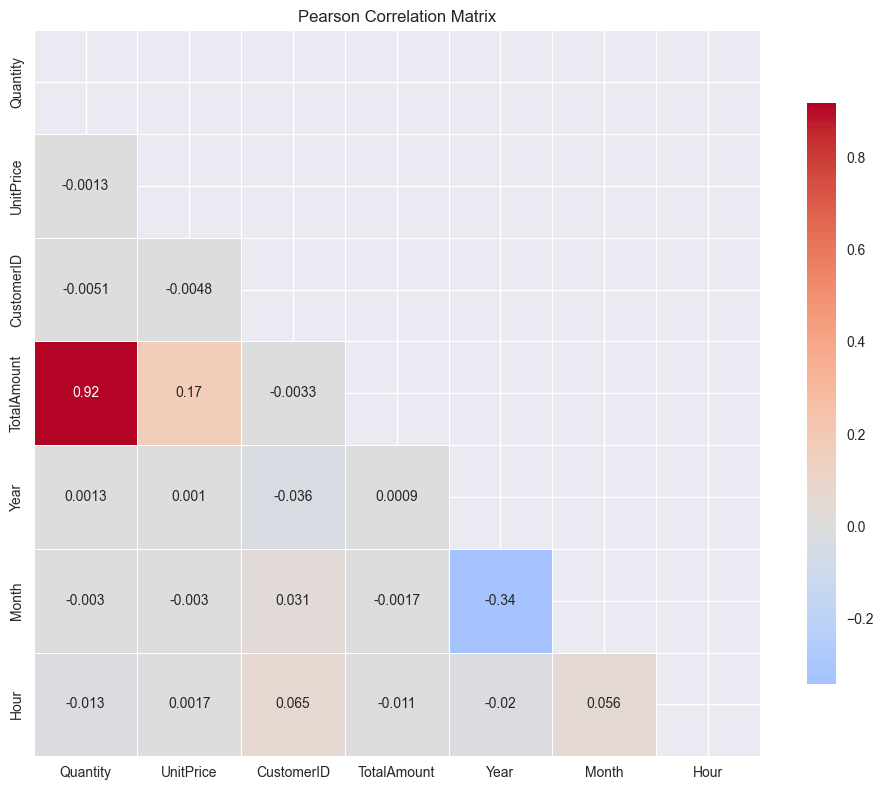

Significant Correlations (|r| >= 0.3):
  Variable_1   Variable_2  Correlation  Abs_Correlation  Strength
0   Quantity  TotalAmount     0.918329         0.918329    Strong
1       Year        Month    -0.341614         0.341614  Moderate

Strongest: Quantity vs TotalAmount (r=0.918)


In [38]:
# Correlation Analysis
correlation_matrix = correlation_analysis(df_clean)
sig_correlations = significant_correlations(correlation_matrix, threshold=0.3)

if not sig_correlations.empty:
    print("Significant Correlations (|r| >= 0.3):")
    print(sig_correlations)
    strongest = sig_correlations.iloc[0]
    print(f"\nStrongest: {strongest['Variable_1']} vs {strongest['Variable_2']} (r={strongest['Correlation']:.3f})")
else:
    print("No significant correlations found above threshold")

In [39]:
# Customer Behavior Analysis
customer_stats, behavior_summary = customer_behavior_analysis(df_clean)
rfm_results = rfm_analysis(df_clean)
segment_counts = rfm_results['Segment'].value_counts()

print("Customer Summary:", ', '.join([f"{k}: {v:.1f}" for k, v in behavior_summary.items()]))
print(f"\nTop 5 Customers by Spending:")
print(customer_stats.nlargest(5, 'Total_Spending')[['Transactions', 'Total_Spending', 'Products']])

print(f"\nRFM Segments: {len(segment_counts)} total")
for segment, count in segment_counts.head(3).items():
    print(f"{segment}: {count} ({count/len(rfm_results)*100:.1f}%)")

Customer Summary: total_customers: 4368.0, avg_transactions_per_customer: 5.1, avg_total_spending: 2183.5, avg_spending_per_transaction: 78.5, avg_customer_lifetime_days: 134.5, avg_products_per_customer: 61.2

Top 5 Customers by Spending:
            Transactions  Total_Spending  Products
CustomerID                                        
16446.0                3       336942.10         3
14646.0               77       281609.90       703
18102.0               62       262876.11       151
17450.0               55       201619.41       127
14911.0              248       155704.20      1794

RFM Segments: 5 total
Champions: 1266 (29.0%)
Lost: 885 (20.3%)
At Risk: 824 (18.9%)


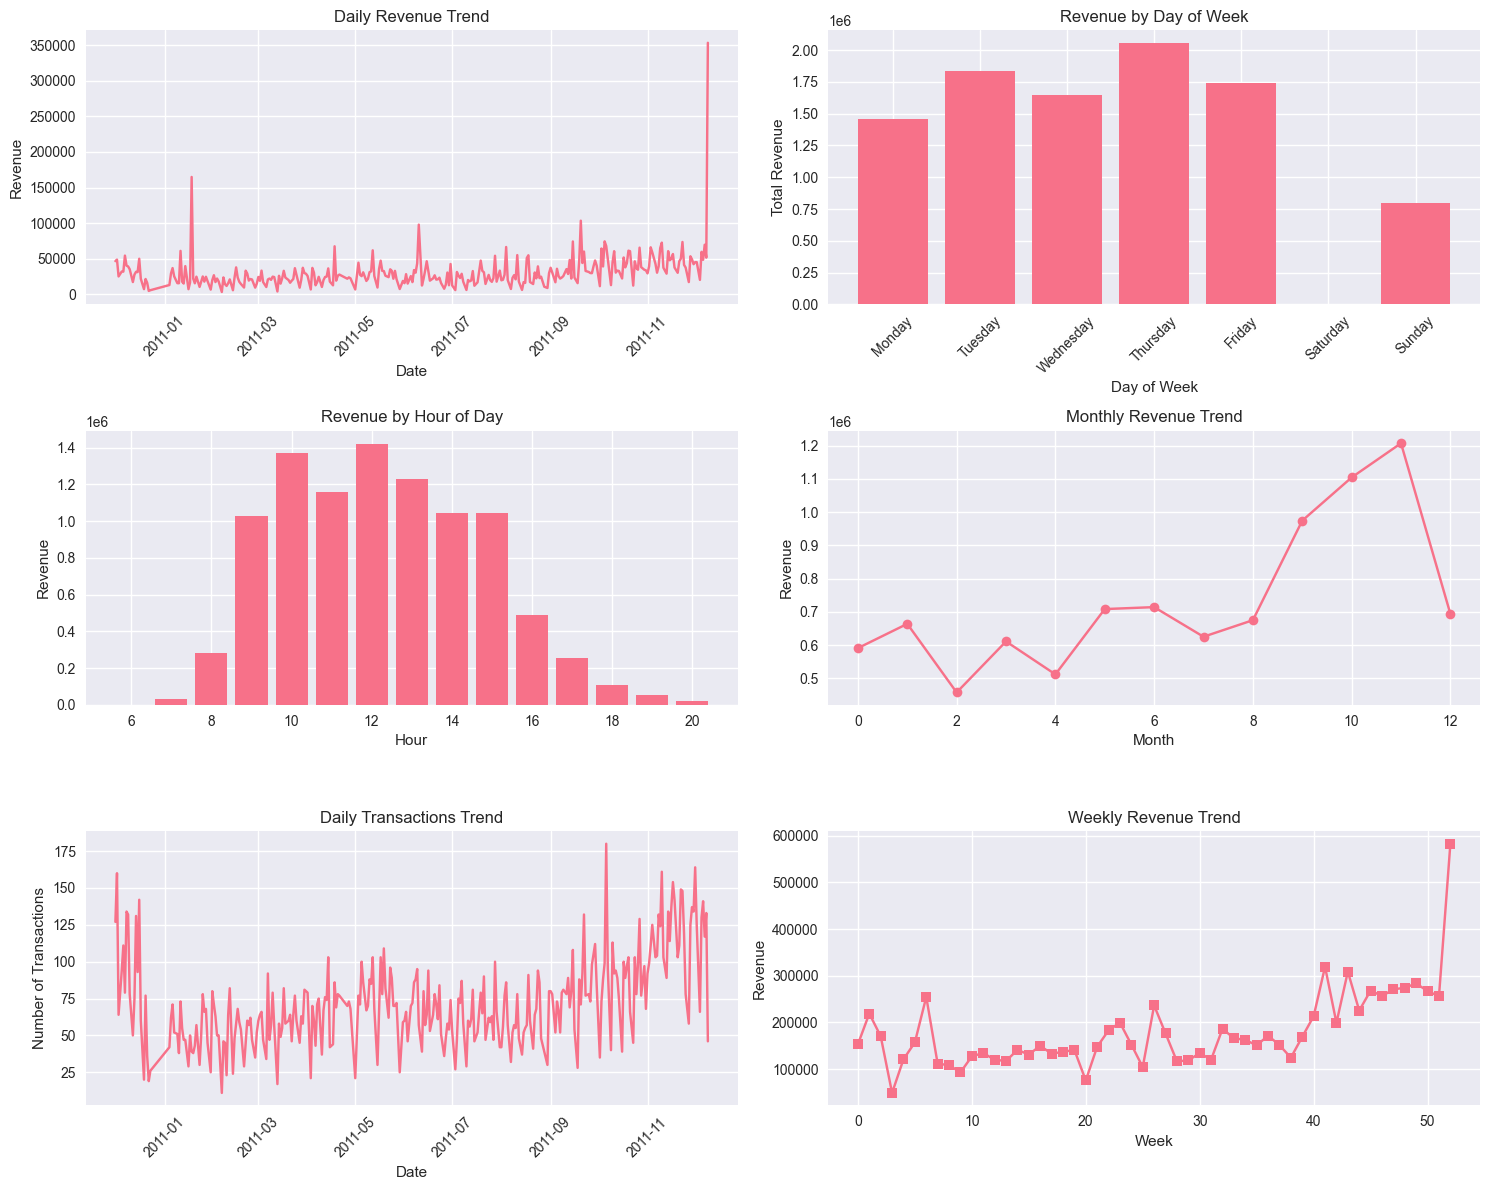

Peak Performance: Thursday at 12:00
Daily Average: $31,271 | Monthly Range: $457,739 - $1,206,793
Trend: Growth


In [40]:
# Temporal Pattern Analysis
temporal_results = temporal_analysis(df_clean)
plot_temporal_trends(temporal_results)

best_day = temporal_results['day_of_week']['DOW_Total_Revenue'].idxmax()
peak_hour = temporal_results['hourly']['Hourly_Total_Revenue'].idxmax()
daily_avg = temporal_results['daily']['Daily_Revenue'].mean()
monthly_revenue = temporal_results['monthly']['Monthly_Revenue']

print(f"Peak Performance: {best_day} at {peak_hour}:00")
print(f"Daily Average: ${daily_avg:,.0f} | Monthly Range: ${monthly_revenue.min():,.0f} - ${monthly_revenue.max():,.0f}")
print(f"Trend: {'Growth' if monthly_revenue.iloc[-1] > monthly_revenue.iloc[0] else 'Decline'}")

In [41]:
# Product and Geographical Analysis
product_results = product_analysis(df_clean, top_n=5)
country_results = country_analysis(df_clean)

print("Top 5 Products by Revenue:")
print(product_results['top_revenue'][['TotalAmount_sum', 'CustomerID_nunique']].head())

print(f"\nTop 5 Countries by Revenue:")
print(country_results[['TotalAmount_sum', 'CustomerID_nunique', 'Revenue_per_Customer']].head())

print(f"\nSummary: {len(product_results['top_revenue'])} products, {len(country_results)} countries")
print(f"Best Product: ${product_results['top_revenue'].iloc[0]['TotalAmount_sum']:,.0f}")
print(f"Best Country: {country_results.index[0]} (${country_results.iloc[0]['TotalAmount_sum']:,.0f})")

Top 5 Products by Revenue:
                                              TotalAmount_sum  \
StockCode Description                                           
23843     PAPER CRAFT , LITTLE BIRDIE               336939.20   
M         Manual                                    170151.84   
23166     MEDIUM CERAMIC TOP STORAGE JAR            158896.37   
22423     REGENCY CAKESTAND 3 TIER                  152417.50   
85123A    WHITE HANGING HEART T-LIGHT HOLDER        107072.45   

                                              CustomerID_nunique  
StockCode Description                                             
23843     PAPER CRAFT , LITTLE BIRDIE                          1  
M         Manual                                             276  
23166     MEDIUM CERAMIC TOP STORAGE JAR                     138  
22423     REGENCY CAKESTAND 3 TIER                           885  
85123A    WHITE HANGING HEART T-LIGHT HOLDER                 858  

Top 5 Countries by Revenue:
                Tot

In [42]:
# Comprehensive Summary
all_results = {
    'stats_summary': stats_summary, 'customer_stats': customer_stats, 'rfm_results': rfm_results,
    'product_results': product_results, 'country_results': country_results, 'temporal_results': temporal_results
}
comprehensive_report = generate_comprehensive_report(df_clean, all_results)

print("ANALYSIS SUMMARY")
print("=" * 40)
ds_info = comprehensive_report['dataset_info']
key_metrics = comprehensive_report['key_metrics']

print(f"Dataset: {ds_info['total_transactions']:,} transactions | {ds_info['total_customers']:,} customers")
print(f"Products: {ds_info['total_products']:,} | Countries: {ds_info['total_countries']}")
print(f"Revenue: ${key_metrics['total_revenue']:,.0f} | Avg Transaction: ${key_metrics['avg_transaction_value']:.2f}")

if 'temporal_insights' in comprehensive_report:
    ti = comprehensive_report['temporal_insights']
    print(f"Peak: {ti['best_day_of_week']} at {ti['peak_hour']}:00")

if 'customer_insights' in comprehensive_report:
    ci = comprehensive_report['customer_insights']
    print(f"Segments: {ci['total_segments']} | Champions: {ci['champion_customers']}")

print("\n✓ All 7 analysis components completed successfully")

ANALYSIS SUMMARY
Dataset: 406,585 transactions | 4,368 customers
Products: 3,684 | Countries: 36
Revenue: $9,537,535 | Avg Transaction: $23.46
Peak: Thursday at 12:00
Segments: 5 | Champions: 1266

✓ All 7 analysis components completed successfully


In [43]:
# Export Results
export: export_analysis_results(all_results)

print("=" * 100)
print("Exports: Customer stats, RFM segments, Product rankings, Country analysis, Temporal patterns")

Analysis results exported to: ../results/
Files created:
   - descriptive_statistics.csv
   - customer_behavior_analysis.csv
   - rfm_analysis.csv
   - product_performance_analysis.csv
   - country_analysis.csv
   - temporal_analysis/daily_analysis.csv
   - temporal_analysis/monthly_analysis.csv
   - temporal_analysis/weekly_analysis.csv
   - temporal_analysis/day_of_week_analysis.csv
   - temporal_analysis/hourly_analysis.csv
Exports: Customer stats, RFM segments, Product rankings, Country analysis, Temporal patterns
